# Executive Summary: Stock Market Analysis (Apple Inc. 2020–2024)
### This analysis focuses on Apple Inc. (AAPL) stock performance from 2020 to 2024. Historical data was pulled using Yahoo Finance, and key visual insights were derived through various plots:

## Price Trend Visualization:

A line chart shows Apple’s stock closing prices over time, indicating strong upward momentum, particularly post-2020 pandemic recovery.

## Moving Averages (MA50 & MA200):

The 50-day and 200-day moving averages were plotted to identify trends and crossovers.

Several Golden Crosses and Death Crosses (bullish and bearish signals) were visible, helping to indicate potential buy/sell periods.

## Candlestick Chart:

A detailed view of price movement with open, high, low, and close data, enabling traders to visually assess volatility and reversal patterns.

## Volume Trends:

Volume bar plots helped spot spikes in trading activity—usually correlated with major news or earnings announcements.

## Returns Analysis:

Daily returns were calculated and plotted to show periods of high volatility and stability.

Cumulative returns showed long-term gains and validated a buy-and-hold strategy.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [2]:
data = yf.download('AAPL', start='2020-01-01', end= '2024-12-31')
data.head()

C:\Users\yuvra\AppData\Local\Temp\ipykernel_2816\3009562451.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2020-01-01', end= '2024-12-31')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.620850,72.681296,71.373226,71.627100,135480400
2020-01-03,71.914810,72.676439,71.689950,71.847110,146322800
2020-01-06,72.487869,72.526556,70.783271,71.034732,118387200
2020-01-07,72.146919,72.753800,71.926892,72.497506,108872000
2020-01-08,73.307503,73.609737,71.849525,71.849525,132079200


In [3]:
close_price = data['Close']['AAPL']

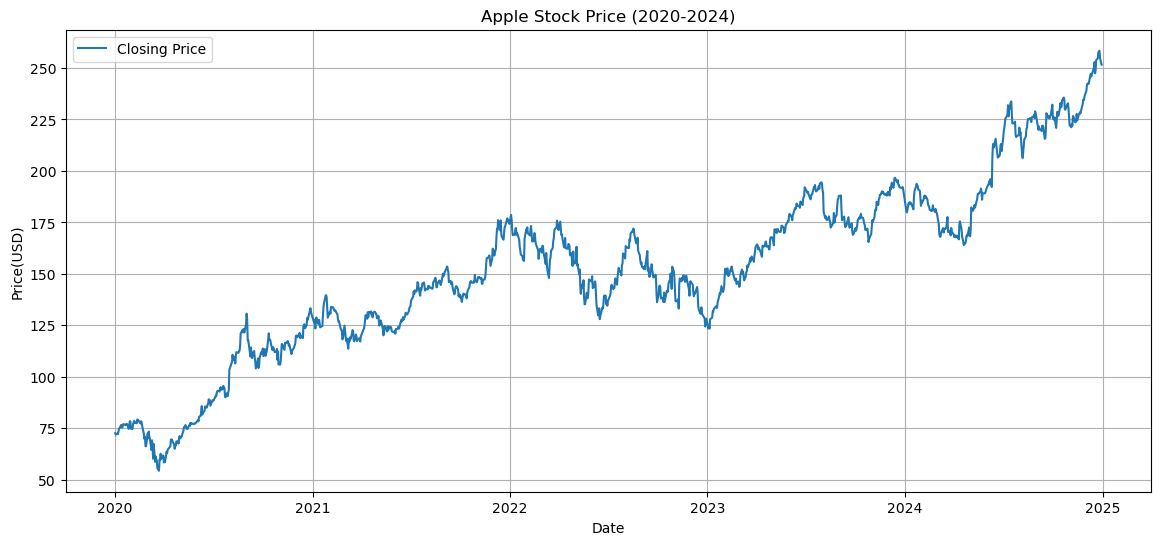

In [4]:
plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='Closing Price')
plt.title('Apple Stock Price (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Price(USD)')
plt.legend()
plt.grid(True)
plt.show()

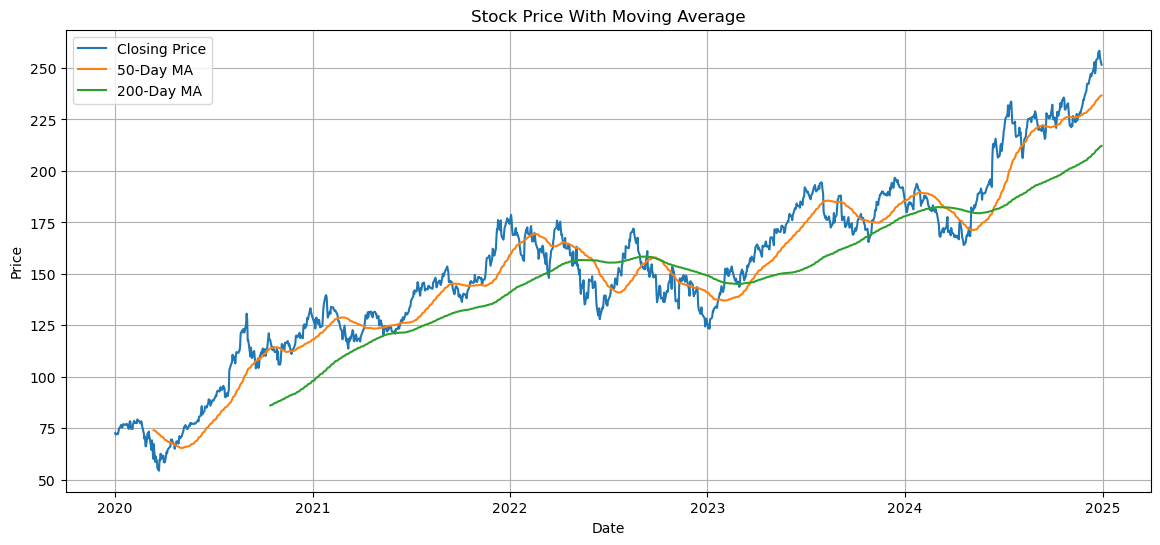

In [5]:
data['MA50'] = data['Close'].rolling(50).mean()
data['MA200'] = data['Close'].rolling(200).mean()

plt.figure(figsize=(14,6))
plt.plot(data['Close'],label ='Closing Price')
plt.plot(data['MA50'],label='50-Day MA')
plt.plot(data['MA200'],label='200-Day MA')
plt.title('Stock Price With Moving Average')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

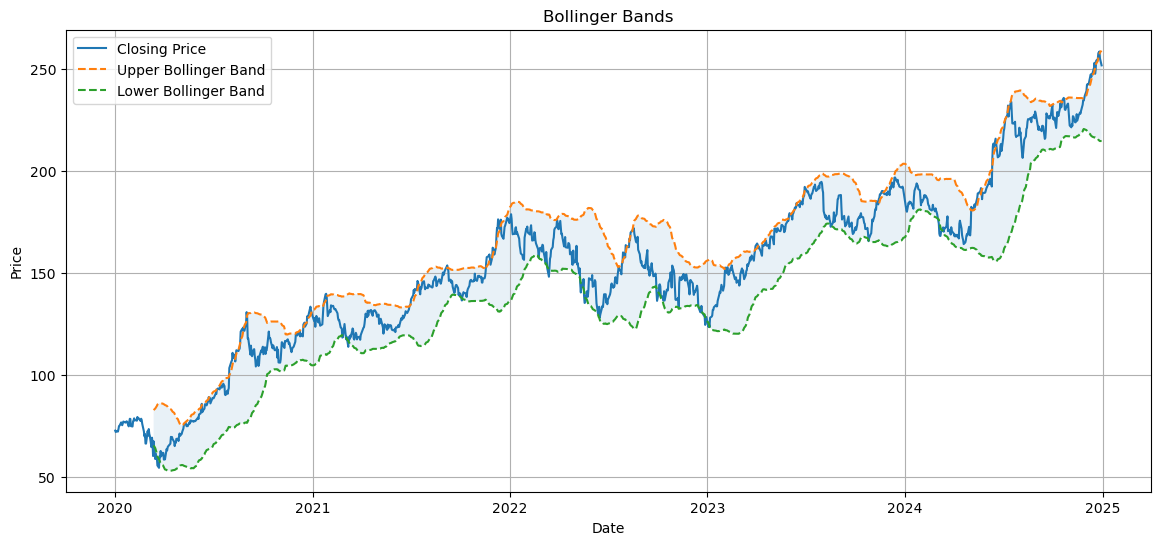

In [6]:
# Calculate 50-day Moving Average
data['MA50'] = close_price.rolling(window=50).mean()

# Calculate Upper and Lower Bollinger Bands
data['UpperBB'] = data['MA50'] + 2 * close_price.rolling(window=50).std()
data['LowerBB'] = data['MA50'] - 2 * close_price.rolling(window=50).std()

# Plot Bollinger Bands
plt.figure(figsize=(14, 6))
plt.plot(data['Close'], label='Closing Price')
plt.plot(data['UpperBB'], label='Upper Bollinger Band', linestyle='--')
plt.plot(data['LowerBB'], label='Lower Bollinger Band', linestyle='--')
plt.fill_between(data.index, data['LowerBB'], data['UpperBB'], alpha=0.1)
plt.title('Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

In [7]:
# Step 7: Compare with Other Stocks
# Compare Apple with Microsoft and Tesla

tickers = ['AAPL', 'MSFT', 'TSLA']
multi_data = yf.download(tickers, start='2020-01-01', end='2024-12-31')

# Extract Close prices
close_prices = multi_data['Close']
print(close_prices.head())

C:\Users\yuvra\AppData\Local\Temp\ipykernel_2816\3685684292.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  multi_data = yf.download(tickers, start='2020-01-01', end='2024-12-31')
[*********************100%***********************]  3 of 3 completed

Ticker           AAPL        MSFT       TSLA
Date                                        
2020-01-02  72.620850  153.042313  28.684000
2020-01-03  71.914810  151.136688  29.534000
2020-01-06  72.487869  151.527298  30.102667
2020-01-07  72.146919  150.145706  31.270666
2020-01-08  73.307503  152.537308  32.809334


In [8]:
# Flatten The Multiindex
flat_data = data.copy()
flat_data.columns = [f'{price} _ {ticker}' for price, ticker in flat_data.columns]
print(flat_data.head())

            Close _ AAPL  High _ AAPL  Low _ AAPL  Open _ AAPL  Volume _ AAPL  \
Date                                                                            
2020-01-02     72.620850    72.681296   71.373226    71.627100      135480400   
2020-01-03     71.914810    72.676439   71.689950    71.847110      146322800   
2020-01-06     72.487869    72.526556   70.783271    71.034732      118387200   
2020-01-07     72.146919    72.753800   71.926892    72.497506      108872000   
2020-01-08     73.307503    73.609737   71.849525    71.849525      132079200   

            MA50 _   MA200 _   UpperBB _   LowerBB _   
Date                                                   
2020-01-02      NaN       NaN         NaN         NaN  
2020-01-03      NaN       NaN         NaN         NaN  
2020-01-06      NaN       NaN         NaN         NaN  
2020-01-07      NaN       NaN         NaN         NaN  
2020-01-08      NaN       NaN         NaN         NaN  


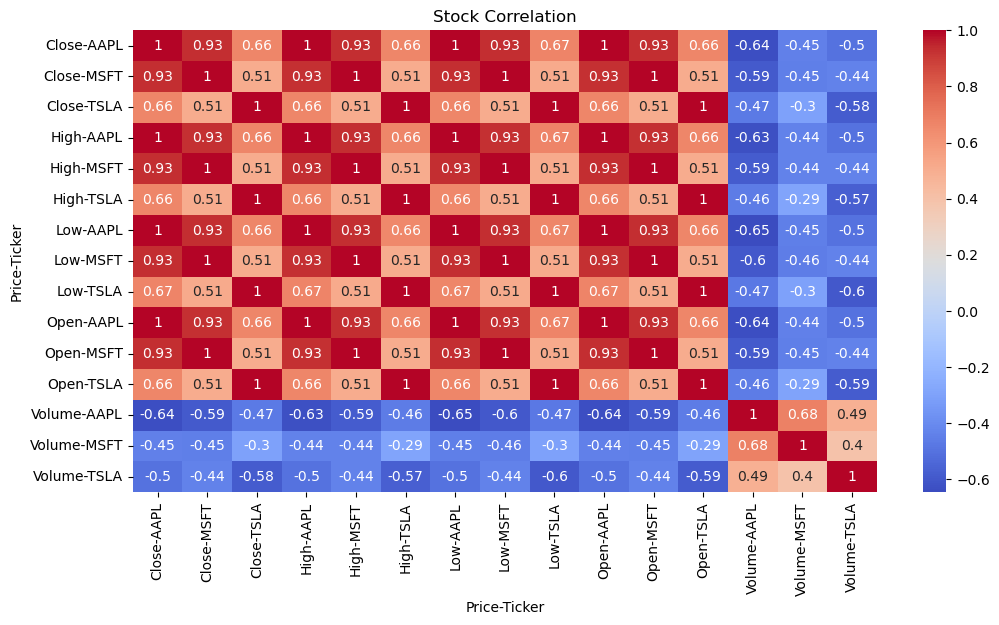

In [15]:
corr = multi_data.corr()
plt.figure(figsize =(12,6))
sns.heatmap(corr, annot= True,cmap='coolwarm')
plt.title('Stock Correlation')
plt.show()